# Project 2 — Part II (d): the SIRVD model and vaccination effectiveness

The stochastic **SIRVD** model is imported from the local library
[`sir_model.py`](sir_model.py) (`simulate_sirvd`): the SIRD model plus a permanently
protected **vaccinated** compartment $V$. Susceptibles now have *two* exits — infection
(rate $\beta I/N$) and vaccination (rate $v$) — so $S$ is sampled from a **Multinomial**
(Algorithm *Stochastic SIRVD simulation*). This notebook only sets up the experiments and
draws the figures.

**What we do.** For each of the three diseases of Appendix~2 — **rubella**, **measles**,
**smallpox** — we keep the **same initial condition** and only change the **effectiveness
of the vaccination campaign**, i.e. the per-capita vaccination rate $v$. The disease rates
come from the appendix exactly as in part (a) but with no exposed state,

$$\gamma+\mu=\frac{1}{\text{infectious}},\qquad
\mu=\frac{\text{CFR}}{\text{infectious}},\qquad
\beta=\frac{R_0}{\text{infectious}} .$$

We interpret the *effectiveness of the campaign* as the rate $v$ at which susceptibles are
vaccinated (the model assumes a vaccinated individual is then perfectly, permanently
protected). We compare three campaigns: **none** ($v=0$), **moderate** ($v=0.02$/day,
≈2 % of the remaining susceptibles vaccinated per day) and **strong** ($v=0.05$/day).

**Initial condition (fixed for all campaigns).** $N=10\,000$ with $I(0)=5$ introduced
infectious cases, so $S(0)=9\,995$ and $V(0)=R(0)=D(0)=0$.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from sir_model import simulate_sirvd

IMAGES = Path("..") / "Images"
IMAGES.mkdir(exist_ok=True)

# --- Disease data (Appendix 2); incubation is unused in SIRVD (no exposed state) -------
DISEASES = {
    "Rubella":  dict(inf=14.0, R0=4.0,  cfr=0.00,  T=320),
    "Measles":  dict(inf=8.0,  R0=15.0, cfr=0.002, T=120),
    "Smallpox": dict(inf=14.0, R0=6.0,  cfr=0.30,  T=220),
}

def sird_rates(d):
    """Map the appendix quantities to SIRD rates (beta = R0/inf, etc.)."""
    out = 1.0 / d["inf"]                       # = gamma + mu
    return dict(beta=d["R0"] * out, gamma=(1.0 - d["cfr"]) * out, mu=d["cfr"] * out)

# Same initial condition for every campaign; only the vaccination rate v changes per panel.
N, I0 = 10000, 5
V_RATES = [0.0, 0.02, 0.05]                    # none / moderate / strong campaign [1/day]
DT, SEED = 0.25, 1

## Derived disease rates

These are identical across the three campaigns; only $v$ changes.

In [2]:
print(f"{'disease':9s} {'beta':>8s} {'gamma':>8s} {'mu':>8s} {'R0':>6s}")
print("-" * 42)
for name, d in DISEASES.items():
    r = sird_rates(d)
    print(f"{name:9s} {r['beta']:8.4f} {r['gamma']:8.4f} {r['mu']:8.4f} {d['R0']:6.1f}")

disease       beta    gamma       mu     R0
------------------------------------------
Rubella     0.2857   0.0714   0.0000    4.0
Measles     1.8750   0.1247   0.0003   15.0
Smallpox    0.4286   0.0500   0.0214    6.0


## One figure per disease

Each figure has three panels — the three campaign strengths $v$ — sharing the **same
initial condition**. On each panel we plot all five compartments $S, I, R, V, D$, with a
numeric summary (peak $I$, fraction ever infected, fraction vaccinated, deaths) printed
alongside.

Rubella   v=0.00  peak I=  4162  ever infected= 98.4%  vaccinated=  0.0%  deaths=  0.0%
Rubella   v=0.02  peak I=   520  ever infected= 20.4%  vaccinated= 79.5%  deaths=  0.0%
Rubella   v=0.05  peak I=    17  ever infected=  0.5%  vaccinated= 99.5%  deaths=  0.0%


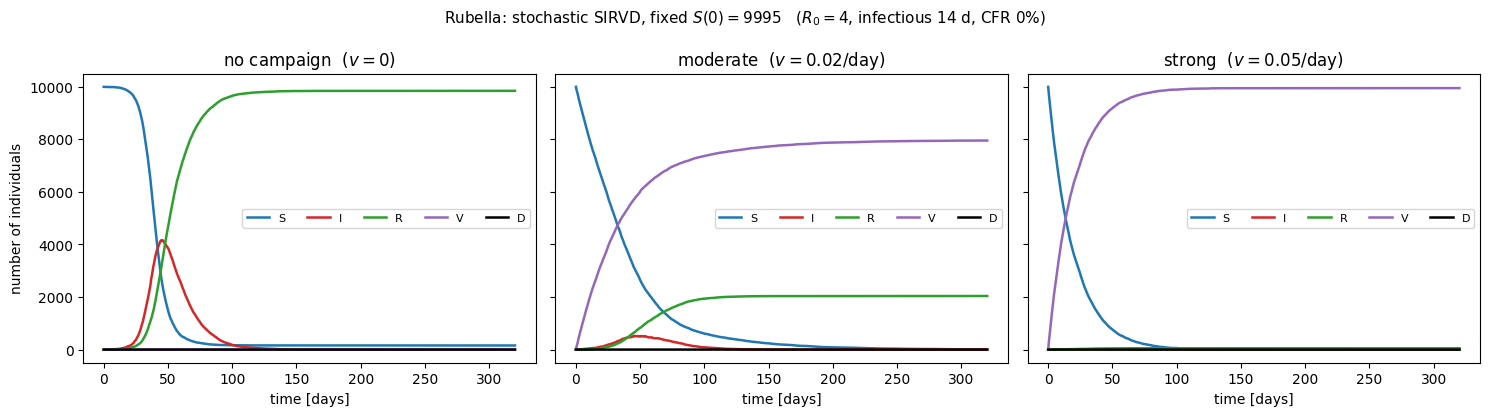

Measles   v=0.00  peak I=  7531  ever infected=100.0%  vaccinated=  0.0%  deaths=  0.2%
Measles   v=0.02  peak I=  6569  ever infected= 89.5%  vaccinated= 10.5%  deaths=  0.2%
Measles   v=0.05  peak I=  5384  ever infected= 75.3%  vaccinated= 24.7%  deaths=  0.1%


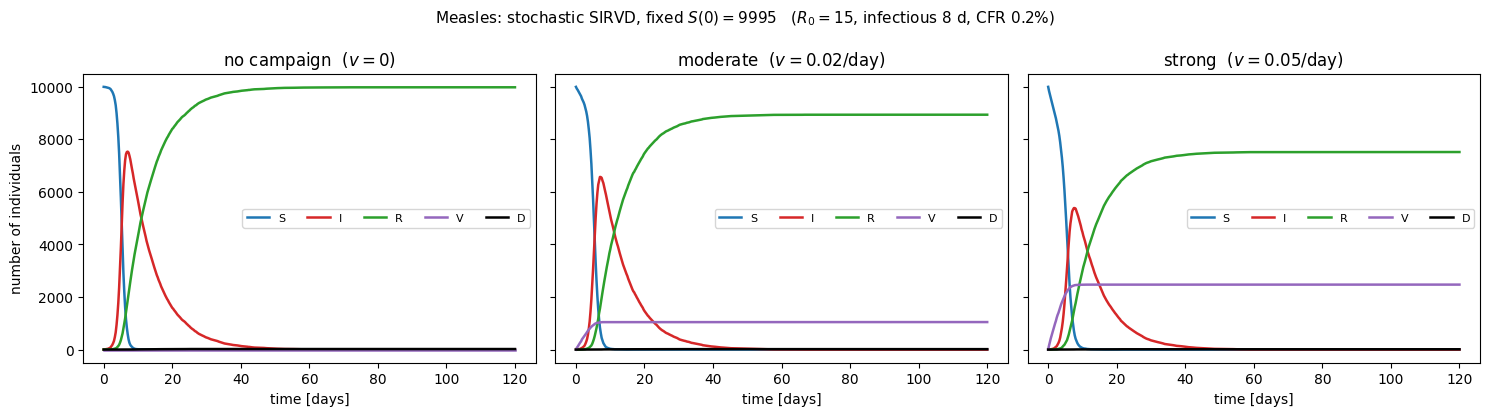

Smallpox  v=0.00  peak I=  5417  ever infected= 99.8%  vaccinated=  0.0%  deaths= 30.5%
Smallpox  v=0.02  peak I=  2652  ever infected= 58.6%  vaccinated= 41.3%  deaths= 17.7%
Smallpox  v=0.05  peak I=   355  ever infected= 10.1%  vaccinated= 89.9%  deaths=  3.2%


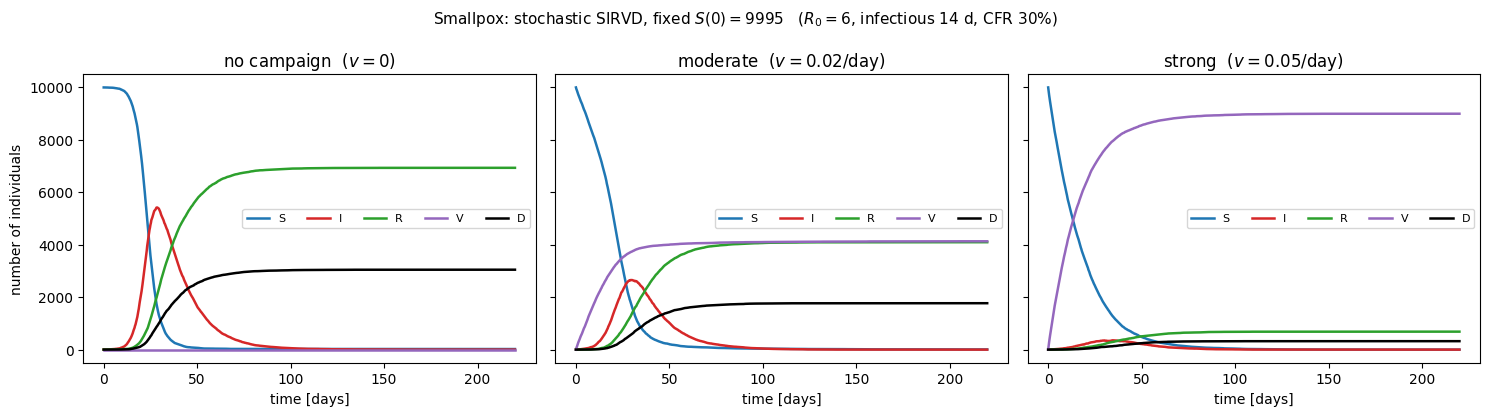

In [3]:
COLORS = {"S": "tab:blue", "I": "tab:red", "R": "tab:green",
          "V": "tab:purple", "D": "black"}
TITLES = {0.0: "no campaign  ($v=0$)", 0.02: "moderate  ($v=0.02$/day)",
          0.05: "strong  ($v=0.05$/day)"}

def plot_disease(name, d):
    r = sird_rates(d)
    fig, axes = plt.subplots(1, len(V_RATES), figsize=(15, 4.2), sharey=True)
    for ax, v in zip(axes, V_RATES):
        rng = np.random.default_rng(SEED)
        t, S, I, R, V, D = simulate_sirvd(
            N, r["beta"], r["gamma"], r["mu"], v, I0=I0, T=d["T"], dt=DT, rng=rng)
        for lab, y in zip("SIRVD", (S, I, R, V, D)):
            ax.plot(t, y, color=COLORS[lab], lw=1.8, label=lab)
        ax.set_title(TITLES[v])
        ax.set_xlabel("time [days]")
        ax.legend(ncol=5, fontsize=8, loc="center right")
        infected = 100 * (N - S[-1] - V[-1]) / N
        print(f"{name:9s} v={v:4.2f}  peak I={I.max():6.0f}  ever infected={infected:5.1f}%  "
              f"vaccinated={100*V[-1]/N:5.1f}%  deaths={100*D[-1]/N:5.1f}%")
    axes[0].set_ylabel("number of individuals")
    fig.suptitle(f"{name}: stochastic SIRVD, fixed $S(0)={N - I0}$   "
                 f"($R_0={d['R0']:g}$, infectious {d['inf']:g} d, CFR {100*d['cfr']:g}%)",
                 fontsize=11)
    fig.tight_layout()
    fig.savefig(IMAGES / f"Proj2_PartIId_{name.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

for name, d in DISEASES.items():
    plot_disease(name, d)

## What the figures show

* **A stronger campaign moves the population from $R/D$ into $V$.** As $v$ grows, the
  vaccinated curve $V$ (purple) climbs and the recovered/dead curves shrink: people who
  would have been infected are instead protected before the infection reaches them. The
  area under $I$ (red) — the size of the outbreak — collapses accordingly.

* **The same campaign is far more effective against a slower disease.** With the *identical*
  strong campaign $v=0.05$/day, rubella ($R_0=4$) is essentially eliminated (≈0.5 % ever
  infected, ~99 % vaccinated), smallpox ($R_0=6$) is largely contained, but measles
  ($R_0=15$) still infects ~75 % of the population — the epidemic simply spreads faster than
  susceptibles can be vaccinated. Vaccination effectiveness therefore depends as much on the
  disease's $R_0$/speed as on the campaign itself.

* **For a lethal disease, vaccination is a direct death-reduction lever.** Smallpox deaths
  fall from ~30 % of the population with no campaign, to ~18 % (moderate), to ~3 % (strong)
  — roughly a tenfold reduction — even though the same number of vaccine doses per day is
  applied as for the other diseases.

* **The campaign keeps draining $S$ even after the outbreak ends.** Because $v$ is constant,
  once $I$ has died out the remaining susceptibles continue to flow into $V$ (visible as $S$
  decaying to ~0 and $V$ saturating), which is what makes the protection permanent and the
  population immune to a re-introduction.